In [1]:
########## LIBRERÍAS A UTILIZAR ##########
#Se importan la librerias a utilizar
import pandas as pd
from sklearn import datasets
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

$\large\textbf{5 MODELADO}$

En esta sección se utilizarán los modelos de clasificación supervisados $\textit{Decision Tree, Regresión Logística, Perceptrón Multicapa}$. Posteriormente, se comparan los resultados en la obtención de la predicción de la matrícula basado en el score ${F}_{1}$, que es la que permite dar la misma importancia a la precisión y la sensibilidad en base al cálculo de su media armónica. Además se evalúa la robustez de cada modelo mediante validación cruzada K-Folds

<img src="https://github.com/mfiguer/notebooks/blob/main/validacion_cruzada.png?raw=true" alt="Alternative text" />

In [2]:
########## LIBRERÍAS A UTILIZAR ##########
#Se importan la librerias a utilizar
import pandas as pd
from sklearn.pipeline import Pipeline
import numpy as np
import seaborn as sns
import scipy
import matplotlib.pyplot as plt
import sklearn.tree # Árboles de decisión
import sklearn.ensemble # Ensambles de modelos
import sklearn.model_selection
import sklearn.decomposition # Módulo donde encontramos el análisis de componentes principales
from sklearn import datasets
from collections import Counter
from statsmodels.stats.multicomp import pairwise_tukeyhsd

$\normalsize\textbf{5.1 Definición de Funciones}$

In [3]:
##########DEFINICIÓN DE FUNCIONES #####
def calcula_metricas(nombre_algoritmo,y_test,y_pred):
### CLASE POSITIVA (1) ###
    #Calculo la precisión del modelo
    from sklearn.metrics import precision_score
    precision = precision_score(y_test, y_pred)

    #Calculo la exactitud del modelo
    from sklearn.metrics import accuracy_score
    exactitud = accuracy_score(y_test, y_pred)

    #Calculo la sensibilidad del modelo
    from sklearn.metrics import recall_score
    sensibilidad = recall_score(y_test, y_pred)

    #Calculo el Puntaje F1 del modelo
    from sklearn.metrics import f1_score
    puntajef1 = f1_score(y_test, y_pred)

    #Calculo la curva ROC - AUC del modelo
    from sklearn.metrics import roc_auc_score
    roc_auc = roc_auc_score(y_test, y_pred)

### CLASE NEGATIVA (0) ###
    from sklearn.metrics import confusion_matrix
    labels = [1, 0]
    cm = confusion_matrix(y_test, y_pred, labels = labels)
    tp,fn,fp,tn = cm.ravel()

    #True Negative Rate / specificity
    TNR_recall_espec = round(tn/(tn+fp),6)

    #Negative Predictive Value
    NPV_precision = round(tn/(tn+fn),6)

    #Cálculo del F1 para la clase negativa
    F1_neg = round(2 * (NPV_precision * TNR_recall_espec) / (NPV_precision + TNR_recall_espec),2)

    ## Vector de Desempeño - Resumen de Métricas del Modelo
    df_1 = pd.DataFrame({'Modelo': [nombre_algoritmo],'Clase ':[1],'Exactitud': [exactitud],'Precisión': [precision],
                   'Sensibilidad': [sensibilidad], 'F1': [puntajef1],'AUC': [roc_auc]})
    df_2 = pd.DataFrame({'Modelo': '','Clase ':[0],'Exactitud': '','Precisión': [NPV_precision],
                   'Sensibilidad': [TNR_recall_espec], 'F1': [F1_neg],'AUC': ''})
   # df = df_1.append(df_2, ignore_index = True)
    df = pd.concat([df_1, df_2], ignore_index=True)

    return df

In [4]:
def matriz_confusion(y_test,y_pred):
    import matplotlib.pyplot as plt
    import seaborn as sns
    #Verifico la matriz de Confusión
    from sklearn.metrics import confusion_matrix
    matriz = confusion_matrix(y_test, y_pred,labels=[1, 0])

    ax = sns.heatmap(matriz, annot=True, cmap='Blues', fmt='g')
    ax.set_title('Matriz de Confusión\n\n');
    ax.set_xlabel('\nPredicción')
    ax.set_ylabel('Real ');

    ## Ticket labels - List must be in alphabetical order
    ax.xaxis.set_ticklabels(['True','False'])
    ax.yaxis.set_ticklabels(['True','False'])

    ## Display the visualization of the Confusion Matrix.
    plt.show()

In [5]:
#Synthetic Minority Oversampling Technique_ + Submuestro de la clase mayoritaria + Balanceo parcial del dataset
# def SMOTE_RUS (X_train,y_train,sample_smote,sample_rus):
#     import imblearn
#     sm = imblearn.over_sampling.SMOTE(sampling_strategy=sample_smote,random_state=11)
#     rus = imblearn.under_sampling.RandomUnderSampler(sampling_strategy=sample_rus,random_state=11)
#     steps = [('SMOTE', sm), ('RUS', rus)] # Ponemos ambos pasos
#     sm_rus = imblearn.pipeline.Pipeline(steps=steps) # Creamos un pipeline para realizar ambas tareas
#     X_train_sm_rus, y_train_sm_rus = sm_rus.fit_resample(X_train, y_train)
#     return X_train_sm_rus,y_train_sm_rus, sm_rus

In [6]:
#Dibuja los scores obtenidos como proceso de evaluación iterativo, recibe los resultados y el valor ideal
def plot_scores(scores, ideal):
    import matplotlib.pyplot as plt
    # creating the dataset
    dic_scores = dict(enumerate(scores.flatten(), 1))
    k = list(dic_scores.keys())
    valores = list(dic_scores.values())

    fig = plt.figure(figsize = (10, 5))

    # creating the xy plot
  #  plt.xlim( [ min(k), max(k) ] )          # Plot from x=0 to x=80.
  #  plt.ylim( [ min(scores), 1 ] )
   #Gráfico XY de los scores vs K-folds
    plt.text(max(k)/2,max(valores)+0.010,'Comportamiento del score', color='steelblue')
    plt.plot(k, valores, color ='steelblue')

    #Mustra línea de umbral establecida
    plt.text(max(k)/2,ideal-0.010,'Umbral de hipótesis',color='mediumblue')
    plt.plot(k,[ideal for _ in range(len(k))],color='mediumblue')

    #Muestra la línea promedio obtenida
    plt.text(max(k)/2,scores.mean()-0.010,'Score promedio',color='brown')
    plt.text(max(k)/2,scores.mean()-0.020, round(scores.mean(),6),color='brown')

    plt.plot(k,[scores.mean() for _ in range(len(k))],color='brown', linestyle='dashed')
    plt.xlabel("k-folds")
    plt.ylabel("score")
    plt.suptitle("Scores de algoritmo evaluado mediante k-fold estratificado")
    plt.title("score ideal del proyecto F1 = 0.8")
    plt.show()

$\normalsize\textbf{5.2 Carga de datos}$

In [7]:
#Carga de datos depurados
data = pd.read_csv("datos_02_bank_validados.csv")
df2 = data.groupby(['deposit'])['deposit'].count()
df2

,deposit
deposit,
0,5872
1,5289


In [8]:
# Separar las variables dependientes de la independientes
y = data['deposit']
X = data.drop(['deposit','fecha_procesamiento'], axis = 1)

#Captura los nombres de las variables independientes
cols = X.columns

#Cuenta la cantidad de registros por cada clase
Counter(y)

Counter({1: 5289, 0: 5872})

$\normalsize\textbf{5.4 Separación de datos Train/Test}$

In [9]:
from sklearn.model_selection import train_test_split

# Se separa el dataset en entrenamiento y prueba.
# IMPORTANTE:
# El conjunto de prueba queda reservado para la evaluación final del modelo.
# Por eso, la validación cruzada se realizará solamente sobre X_train_raw e y_train_raw.
X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

$\normalsize\textbf{5.3 Escalamiento de datos}$

In [10]:
from sklearn.preprocessing import MinMaxScaler

# IMPORTANTE:
# El escalador se ajusta solamente con el conjunto de entrenamiento original.
# Así se evita fuga de datos desde el conjunto de prueba.
escalar = MinMaxScaler()

X_train = escalar.fit_transform(X_train_raw)  # aprende mínimos y máximos solo desde entrenamiento
X_test = escalar.transform(X_test_raw)        # aplica la misma escala al conjunto de prueba

In [11]:
# Cuenta la cantidad de registros por cada clase del conjunto de entrenamiento original
Counter(y_train_raw)

Counter({1: 4231, 0: 4697})

$\normalsize\textbf{5.4 Balanceo de clases}$

In [12]:
# Invocar función SMOTE + RUS solamente sobre el conjunto de entrenamiento escalado
# IMPORTANTE:
# El balanceo no se aplica sobre X_test, porque el conjunto de prueba debe representar datos no vistos.
# X_train, y_train, pipeline_balanceo = SMOTE_RUS(X_train, y_train_raw, 0.5, 0.75)

# Cuenta la cantidad de registros del set de entrenamiento post balanceo
# Counter(y_train)

$\normalsize\textbf{5.5 Arboles de Decisión}$

En esta sección se aplicará el entrenamiento y evaluación modelo $\textit{DecisionTreeClassifier}$ para la predicción de la matrícula

$\textbf{5.5.2 Evaluación del modelo Decision Tree Classifier}$

In [13]:
# Instanciar el clasificador basado en Arboles de decisión
from sklearn.tree import DecisionTreeClassifier
tree_clf = DecisionTreeClassifier(max_depth=8,criterion = 'entropy')

In [14]:
#Entreno el modelo
tree_clf.fit(X_train, y_train_raw)

DecisionTreeClassifier(criterion='entropy', max_depth=8)

In [15]:
#Realizo una predicción
y_pred = tree_clf.predict(X_test)

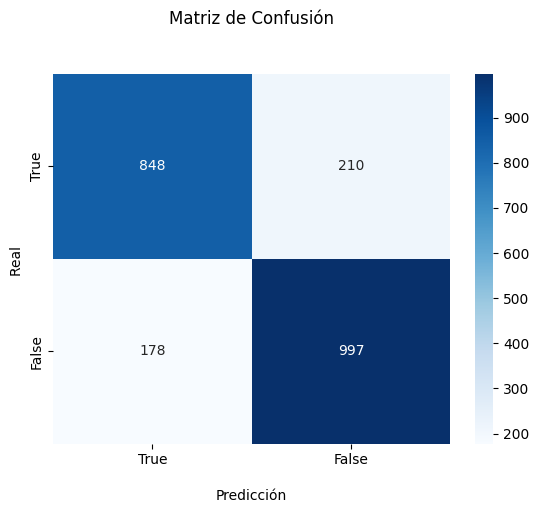

In [16]:
#Calcula y despliega la matriz de confusión
matriz_confusion(y_test,y_pred)

In [17]:
#Obtiene las métricas del modelo
df_metricas_tree = calcula_metricas('Tree',y_test,y_pred)
#df_metricas_tree.style.hide_index()
df_metricas_tree.style.hide(axis="index")

Modelo,Clase,Exactitud,Precisión,Sensibilidad,F1,AUC
Tree,1,0.826243,0.826511,0.801512,0.813820,0.825011
,0,,0.826015,0.848511,0.840000,


A continuación se aplicación de $\textit{K-Folds Stratified}$ para evaluar la estabilidad del rendimiento del modelo frente a multiples sets de entrenamiento

In [18]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from numpy import mean

# Pipeline completo para validación cruzada:
# En cada fold se ajusta el escalador solo con el subconjunto de entrenamiento del fold.
# Luego se aplica SMOTE + RUS solo sobre ese subconjunto de entrenamiento.
# Finalmente se entrena y evalúa el modelo evitando fuga de datos.
#
# IMPORTANTE:
# Como existe un conjunto de prueba final separado, la validación cruzada se realiza
# solamente sobre X_train_raw e y_train_raw, no sobre X e y completos.
pipeline_tree = Pipeline([
    ('scaler', MinMaxScaler()),
    ('tree', DecisionTreeClassifier(max_depth=8, criterion='entropy'))
])

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

tree_scores = cross_val_score(
    pipeline_tree,
    X_train_raw,
    y_train_raw,
    scoring='f1',
    cv=cv,
    n_jobs=-1
)

score = round(tree_scores.mean(), 6)
print('F1 promedio: %.3f' % score)

F1 promedio: 0.798


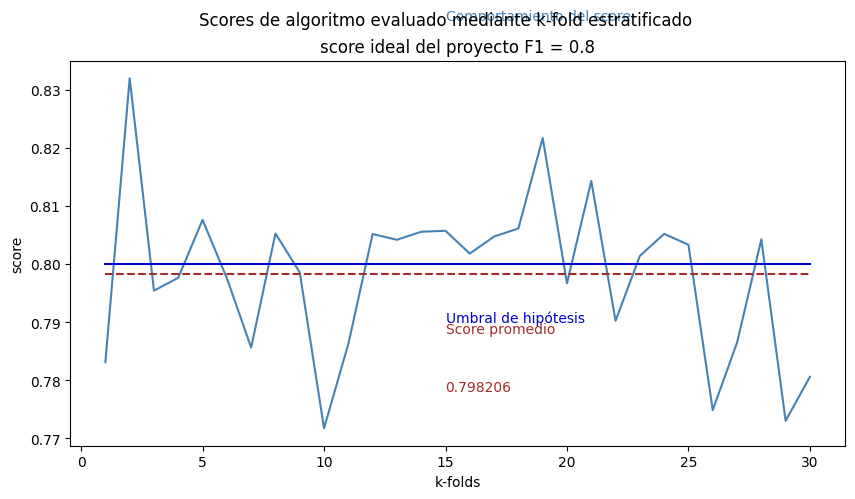

In [19]:
#Dibuja los scores obtenidos como proceso de evaluación iterativo, recibe los resultados y el valor ideal
plot_scores(tree_scores, 0.8)

Viendo los resultados anteriores se observa que el algoritmo tiene un rendimiento estable frente a los conjuntos de entrenamiento y existe bajo riesgo de overfitting

$\normalsize\textbf{5.6 Regresión Logística}$

En esta sección se aplicará el entrenamiento y evaluación modelo $\textit{LogisticRegression}$ para la predicción de la matrícula

Dados los resultados anteriores se usará el algoritmo con los mejores hiperparámetros

$\textbf{5.6.2 Evaluación del modelo Logistic Regression}$

In [20]:
#Defino el algoritmo a utilizar
from sklearn.linear_model import LogisticRegression
lr_clf = LogisticRegression()

In [21]:
#Entreno el modelo
lr_clf.fit(X_train, y_train_raw)

LogisticRegression()

In [22]:
#Realizo una predicción
y_pred = lr_clf.predict(X_test)

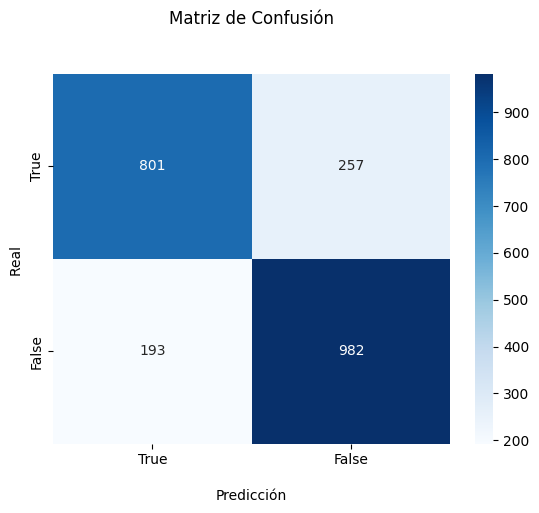

In [23]:
#Calcula y despliega la matriz de confusión
matriz_confusion(y_test,y_pred)

In [24]:
#Obtiene las métricas del modelo
df_metricas_lr = calcula_metricas('Regresión Logística',y_test,y_pred)
#df_metricas_lr.style.hide_index()
df_metricas_lr.style.hide(axis="index")

Modelo,Clase,Exactitud,Precisión,Sensibilidad,F1,AUC
Regresión Logística,1,0.798477,0.805835,0.757089,0.780702,0.796417
,0,,0.792575,0.835745,0.810000,


A continuación se aplicación de $\textit{K-Folds Stratified}$ para evaluar la estabilidad del rendimiento del modelo frente a multiples sets de entrenamiento

In [25]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from numpy import mean

# Pipeline completo para Regresión Logística en validación cruzada.
# El escalado y el balanceo se realizan dentro de cada fold, evitando fuga de datos.
#
# IMPORTANTE:
# Como existe un conjunto de prueba final separado, la validación cruzada se realiza
# solamente sobre X_train_raw e y_train_raw, no sobre X e y completos.
pipeline_lr = Pipeline([
    ('scaler', MinMaxScaler()),
    ('lr', LogisticRegression(max_iter=1000))
])

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

lr_scores = cross_val_score(
    pipeline_lr,
    X_train_raw,
    y_train_raw,
    scoring='f1',
    cv=cv,
    n_jobs=-1
)

score = round(lr_scores.mean(), 6)
print('F1 promedio: %.3f' % score)

F1 promedio: 0.781


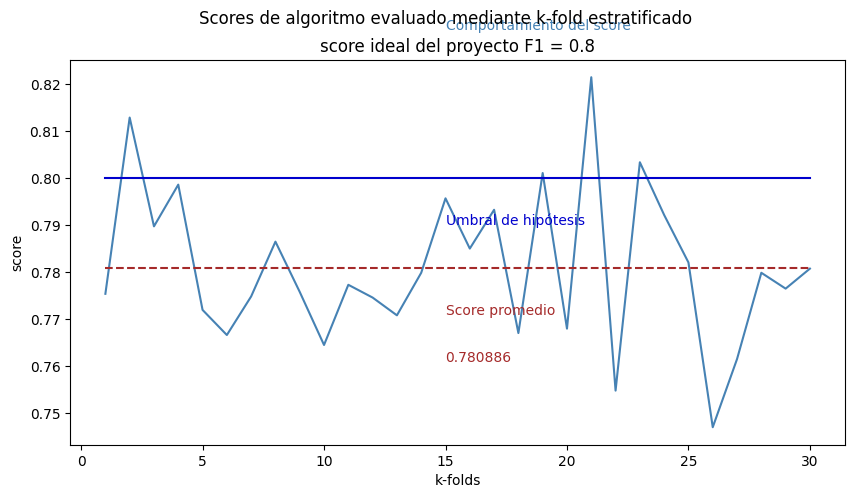

In [26]:
#Dibuja los scores obtenidos como proceso de evaluación iterativo, recibe los resultados y el valor ideal
plot_scores(lr_scores, 0.8)

Viendo los resultados anteriores se observa que el algoritmo tiene un rendimiento estable frente a los conjuntos de entrenamiento y existe bajo riesgo de overfitting

$\normalsize\textbf{5.7 Redes Neuronales - Perceptrón Multicapa}$

En esta sección se aplicará el entrenamiento y evaluación modelo $\textit{MLPClassifier}$ para la predicción de la matrícula

$\textbf{5.7.2 Evaluación del modelo MLP Classifier}$

In [27]:
# Perceptrón Multicapa MLP (neuronas, capas)
# hidden_layer_sizes=(100,) indica una capa oculta con 100 neuronas.
from sklearn.neural_network import MLPClassifier
mlp_clf = MLPClassifier(random_state=0, hidden_layer_sizes=(100,), max_iter=1000)


In [28]:
#Entreno el modelo
mlp_clf.fit(X_train, y_train_raw)

MLPClassifier(max_iter=1000, random_state=0)

In [29]:
#Realizo una predicción
y_pred = mlp_clf.predict(X_test)

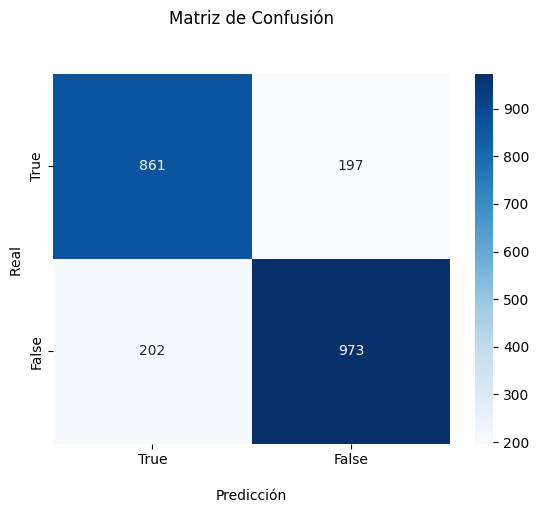

In [30]:
#Calcula y despliega la matriz de confusión
matriz_confusion(y_test,y_pred)

In [31]:
#Obtiene las métricas del modelo
df_metricas_mlp = calcula_metricas('MLP',y_test,y_pred)
df_metricas_mlp

,Modelo,Clase,Exactitud,Precisión,Sensibilidad,F1,AUC
0,MLP,1,0.821317,0.809972,0.813800,0.811881,0.820942
1,,0,,0.831624,0.828085,0.830000,


A continuación se aplicación de $\textit{K-Folds Stratified}$ para evaluar la estabilidad del rendimiento del modelo frente a multiples sets de entrenamiento

In [32]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPClassifier
from numpy import mean

# Pipeline completo para MLP en validación cruzada.
# El escalado y el balanceo se realizan dentro de cada fold, evitando fuga de datos.
#
# IMPORTANTE:
# Como existe un conjunto de prueba final separado, la validación cruzada se realiza
# solamente sobre X_train_raw e y_train_raw, no sobre X e y completos.
pipeline_mlp = Pipeline([
    ('scaler', MinMaxScaler()),
    ('mlp', MLPClassifier(random_state=0, hidden_layer_sizes=(100,), max_iter=1000))
])

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

mlp_scores = cross_val_score(
    pipeline_mlp,
    X_train_raw,
    y_train_raw,
    scoring='f1',
    cv=cv,
    n_jobs=-1
)

score = round(mlp_scores.mean(), 6)
print('F1 promedio: %.3f' % score)

F1 promedio: 0.812


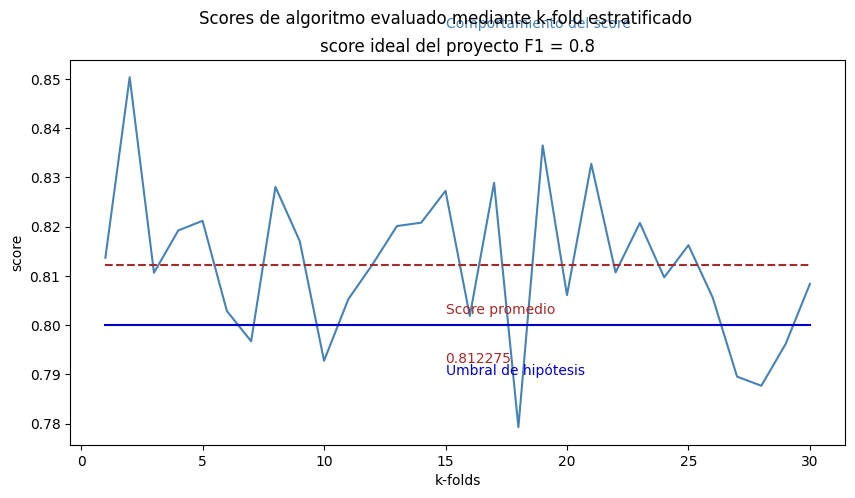

In [33]:
#Dibuja los scores obtenidos como proceso de evaluación iterativo, recibe los resultados y el valor ideal
plot_scores(mlp_scores, 0.8)

$\large\textbf{6 EVALUACIÓN}$<br><br>
En esta sección se desarrolla la evaluación de resultados obtenidos para la obtención de las conclusiones finales. El primer análisis evalutativo se realizó a través de la tabla consolidada de métricas tras realizar los experimentos desplegados en este informe, con el conjunto de datos de entrenamiento y test elegido con la técnica de split, train, test con un ${20\%}$ de datos para las prueba.

$\textbf{6.1 Evaluación a priori}$

In [34]:
# Consolida todas las métricas obtenidas antes del proceso de validación cruzada
df_metricas_consolidadas = pd.concat(
    [df_metricas_tree, df_metricas_lr, df_metricas_mlp],
    ignore_index=True
)

df_metricas_consolidadas.style.hide(axis="index")

Modelo,Clase,Exactitud,Precisión,Sensibilidad,F1,AUC
Tree,1,0.826243,0.826511,0.801512,0.813820,0.825011
,0,,0.826015,0.848511,0.840000,
Regresión Logística,1,0.798477,0.805835,0.757089,0.780702,0.796417
,0,,0.792575,0.835745,0.810000,
MLP,1,0.821317,0.809972,0.813800,0.811881,0.820942
,0,,0.831624,0.828085,0.830000,


De la tabla anterior, se desprende que los algoritmos utilizados para predecir la matricula, tienen un rendimiento muy similar con el dataset trabajado en este proyecto, y en la métrica que interesa para evaluar la hipótesis ($\textbf{F}_{1}$), es superior el algoritmo $\textit{Decision Tree}$, por lo que sería un candidato a elegir, sin embargo, no alcanza el umbral de la hipótesis para la clase positiva que predice la matricula, pero si el $\textbf{F}_{1}$ para la clase negativa alcanza sobre el ${90\%}$ en todos, por lo que son muys buenos todos haciendo la predicción cuando algun postulante no se matriculará.<br><br>
Para complementar el análisis anterior, se utilizarán los resultados obtenidos del proceso de validación cruzada, con lo que fue posible realizar una serie de particiones del conjunto de datos, para así obtener un rendimiento promedio de cada método al utilizar distintos conjuntos de entrenamiento y prueba. Esto también nos permite aplicar pruebas estadísticas a nuestras métricas y así poder seleccionar el mejor modelo con mayor certeza.

In [35]:
# Guardamos todos los resultados obtenido en los procesos de Cross Validation en una lista
scores = [tree_scores,lr_scores,mlp_scores]

#Nombres de los algoritmos utilizados
modelos = ["Decision Tree","Logistic Regression","Multilayer Perceptron"]

Con esta visualización podemos ver la distribución de resultados para cada uno de los algoritmos seleccionados.

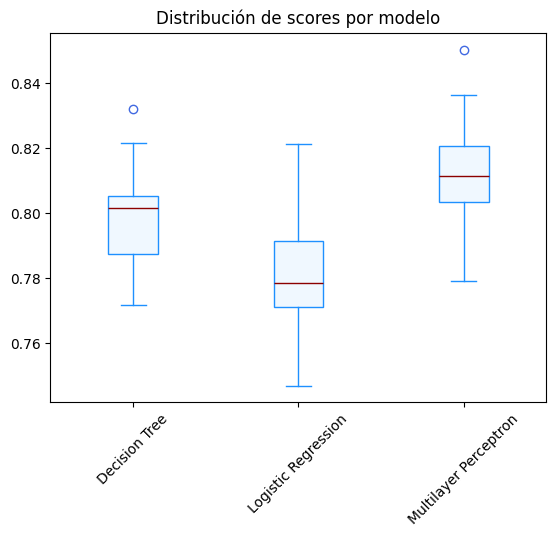

In [36]:
#Generar un diagrama de caja para ver la distribución de datos por cada predictor de matriculas.
#Usando boxplot, podemos detectar fácilmente las diferencias entre diferentes predictores de matriculas
plt.title("Distribución de scores por modelo")
plt.boxplot(scores,labels = modelos,patch_artist=True,
           boxprops=dict(facecolor="aliceblue",color ="dodgerblue"),
           whiskerprops=dict(color ="dodgerblue"),
           medianprops = dict(color ="darkred"),
           flierprops=dict(markeredgecolor ="royalblue"),
           capprops = dict(color ="dodgerblue"))

plt.xticks(rotation=45)
plt.show()

Extraemos el resultado promedio de cada uno de los algoritmos. Los diagramas de caja muestran que todos los algoritmos tienen un buen comportamiento respecto de la varianza de los resultados. A priori, en el caso de $\textit{Decision Tree}$, se observa un promedio más elevado y  varianza similar con respecto a los demás.

In [37]:
#Crea diccionario modelos y promedio del score
dict_score_means = dict(
    zip(
        modelos,
        map(
            np.mean,
            scores
        )
    )
)
df_score_means = pd.DataFrame.from_dict(dict_score_means,orient = 'index',  columns = ['Score mean'])
df_score_means.style.highlight_max(color = 'powderblue', axis = 0)

,Score mean
Decision Tree,0.798206
Logistic Regression,0.780886
Multilayer Perceptron,0.812275


In [38]:
# ============================================================
# GUARDAR SOLO EL CLASIFICADOR CON MEJOR F1 USANDO JOBLIB
# Y SIMULAR UNA INFERENCIA POSTERIOR
# ============================================================

import numpy as np
import pandas as pd
import joblib

# ------------------------------------------------------------
# 1. Comparar los modelos según el F1 promedio de Cross Validation
# ------------------------------------------------------------

f1_tree = np.mean(tree_scores)
f1_lr = np.mean(lr_scores)
f1_mlp = np.mean(mlp_scores)

resultados_f1 = pd.DataFrame({
    "Modelo": ["Decision Tree", "Logistic Regression", "Multilayer Perceptron"],
    "F1 Promedio": [f1_tree, f1_lr, f1_mlp]
})

display(resultados_f1)

# ------------------------------------------------------------
# 2. Seleccionar el mejor clasificador ya entrenado
# ------------------------------------------------------------

mejor_indice = resultados_f1["F1 Promedio"].idxmax()
mejor_modelo_nombre = resultados_f1.loc[mejor_indice, "Modelo"]
mejor_f1 = resultados_f1.loc[mejor_indice, "F1 Promedio"]

if mejor_modelo_nombre == "Decision Tree":
    mejor_clf = tree_clf
elif mejor_modelo_nombre == "Logistic Regression":
    mejor_clf = lr_clf
else:
    mejor_clf = mlp_clf

print("Mejor modelo seleccionado:", mejor_modelo_nombre)
print("F1 promedio:", round(mejor_f1, 4))

,Modelo,F1 Promedio
0,Decision Tree,0.798206
1,Logistic Regression,0.780886
2,Multilayer Perceptron,0.812275


Mejor modelo seleccionado: Multilayer Perceptron
F1 promedio: 0.8123


In [39]:
# ------------------------------------------------------------
# 3. Guardar solo el clasificador en un archivo .joblib
# ------------------------------------------------------------

nombre_archivo = "predictor_bank_tree.joblib"

joblib.dump(mejor_clf, nombre_archivo)

print("Modelo guardado correctamente en:", nombre_archivo)

# ------------------------------------------------------------
# 4. Descargar el archivo si estás usando Google Colab
# ------------------------------------------------------------

try:
    from google.colab import files
    files.download(nombre_archivo)
except:
    print("No se detectó Google Colab. El modelo quedó guardado en la carpeta del notebook.")

Modelo guardado correctamente en: predictor_bank_tree.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
# ============================================================
# CARGAR MODELO Y SIMULAR PREDICCIÓN CON VALORES FICTICIOS
# ============================================================

import pandas as pd
import joblib

# ------------------------------------------------------------
# 1. Cargar el clasificador guardado
# ------------------------------------------------------------

modelo_cargado = joblib.load(nombre_archivo)

print("Modelo cargado correctamente.")

Modelo cargado correctamente.


In [41]:
# ------------------------------------------------------------
# 2. Crear un registro ficticio con las mismas variables usadas
#    para entrenar el modelo
# ------------------------------------------------------------

registro_ficticio = pd.DataFrame([{
  "age": 59,
  "job": 0,
  "marital": 1,
  "education": 1,
  "default": 0,
  "balance": 2343,
  "housing": 1,
  "loan": 0,
  "contact": 2,
  "day": 5,
  "month": 8,
  "duration": 1042,
  "campaign": 1,
  "pdays": -1,
  "previous": 0,
  "poutcome": 3,
  "es_cliente_nuevo": 1,
  "tiene_doble_prestamo": 0,
  "duration_min": 17.366667
}])

print("Registro ficticio ingresado:")
display(registro_ficticio)

Registro ficticio ingresado:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,es_cliente_nuevo,tiene_doble_prestamo,duration_min
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1,0,17.366667


In [42]:
# ------------------------------------------------------------
# 3. Escalar el registro ficticio
# ------------------------------------------------------------
# IMPORTANTE:
# Como guardamos solo el clasificador, debemos transformar
# manualmente el registro usando el mismo escalador ya ajustado.

registro_ficticio_escalado = escalar.transform(registro_ficticio)

# ------------------------------------------------------------
# 4. Realizar predicción de clasificación
# ------------------------------------------------------------

prediccion = modelo_cargado.predict(registro_ficticio_escalado)

print("Clasificación predicha ESTADO:", prediccion[0])

Clasificación predicha ESTADO: 1


In [43]:
# ------------------------------------------------------------
# 5. Obtener probabilidades por clase
# ------------------------------------------------------------

probabilidades = modelo_cargado.predict_proba(registro_ficticio_escalado)

df_probabilidades = pd.DataFrame({
    "Clase ESTADO": modelo_cargado.classes_,
    "Probabilidad": probabilidades[0]
})

print("Probabilidades de clasificación:")
display(df_probabilidades)

Probabilidades de clasificación:


,Clase ESTADO,Probabilidad
0,0,0.160696
1,1,0.839304
